# Supermarket Sales Analysis 🛒

# Data Manipulation with Pandas: Comprehensive Analytics Project 


## 1: Introduction & Overview
This project serves as a comprehensive, end-to-end application of **Data Manipulation using Pandas**, the world's most popular Python library for data science. In real-world data analytics, raw data is rarely ready for immediate decision-making. It requires efficient importing, inspecting, filtering, and summarizing to uncover meaningful business insights.

The core objective of this notebook is to document and apply fundamental data science operations through a structured, multi-phase analytical workflow based on standard industry practices.

### 1.1: Data Exploration, Importing & Loading
In this initial phase, we focus on setting up our workspace, importing the `pandas` library, and loading our cleaned real-world dataset. We will then inspect its structure using fundamental exploratory functions.

In [48]:
import pandas as pd
import numpy as np

# Load the cleaned dataset
df = pd.read_csv("../datasets/supermarket_analysis.csv")

# Display the first 5 rows (The .head() method)
df.head()


,Invoice ID,City,Customer type,Gender,Product line,Quantity,Sales,Date,Payment
0,750-67-8428,Yangon,Member,Female,Health and beauty,7,548.9715,1/5/2019,Ewallet
1,226-31-3081,Naypyitaw,Normal,Female,Electronic accessories,5,80.2200,3/8/2019,Cash
2,631-41-3108,Yangon,Normal,Female,Home and lifestyle,7,340.5255,3/3/2019,Credit card
3,123-19-1176,Yangon,Member,Female,Health and beauty,8,489.0480,1/27/2019,Ewallet
4,373-73-7910,Yangon,Member,Female,Sports and travel,7,634.3785,2/8/2019,Ewallet


###  1.2 Dataset Structural Inspection
Now, we will utilize fundamental Pandas attributes and methods to inspect the dataset's shape, column names, and internal structural information.

* **`.shape`**: To check total rows and columns.
* **`.info()`**: To inspect data types and check for missing values.
* **`.columns` & `.index`**: To extract structural metadata.


In [4]:
# Check dataset dimensions (Rows, Columns) 
df.shape

(1000, 9)

In [5]:
# Inspect data types and structural integrity 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Invoice ID     1000 non-null   object 
 1   City           1000 non-null   object 
 2   Customer type  1000 non-null   object 
 3   Gender         1000 non-null   object 
 4   Product line   1000 non-null   object 
 5   Quantity       1000 non-null   int64  
 6   Sales          1000 non-null   float64
 7   Date           1000 non-null   object 
 8   Payment        1000 non-null   object 
dtypes: float64(1), int64(1), object(7)
memory usage: 70.4+ KB


In [6]:
# Extract and display column names
print("Columns:", df.columns)

# Extract and display row index info
print("Index:", df.index)

Columns: Index(['Invoice ID', 'City', 'Customer type', 'Gender', 'Product line',
       'Quantity', 'Sales', 'Date', 'Payment'],
      dtype='object')
Index: RangeIndex(start=0, stop=1000, step=1)


---
### 1.3: Data Integrity & Quality Assurance (Missing Data Check)

In real-world data science pipelines, verifying data completeness is a mandatory step before finalizing any analytical framework. In this section, we conduct a comprehensive integrity check on our actual supermarket dataset to ensure there are no unrecorded values.

####  Core Programmatic Tools for Inspection:
* **`.isna()`**: Scans the entire structural matrix cell-by-cell and returns logical values (`True` for empty cells, `False` for populated cells).
* **`.any()`**: Provides a quick boolean validation per column to report whether at least one missing record exists.
* **`.sum()`**: Aggregates individual omissions across columns, turning individual detections into an actionable numeric frequency report.

####  Core Programmatic Tools for Remediation (If Missing Values are Found):
* **`.dropna()`**: A definitive clean-up tool used to purge and remove entire rows or columns that contain missing records from the structural layout.
* **`.fillna()`**: A flexible interpolation tool used to substitute empty fields with a default static baseline (such as 0 or the statistical column mean) to avoid analytical fractures.


In [56]:
# 1. Quick boolean audit to verify if ANY column contains missing data
print("--- Boolean Missing Data Audit (.any) ---")
print(df.isna().any())
print("\n")

--- Boolean Missing Data Audit (.any) ---
Invoice ID       False
City             False
Customer type    False
Gender           False
Product line     False
Quantity         False
Sales            False
Date             False
Payment          False
dtype: bool




In [57]:
# 2. Detailed frequency breakdown counting the exact number of missing values per column
print("--- Final Missing Data Frequency Count (.sum) ---")
df.isna().sum()

--- Final Missing Data Frequency Count (.sum) ---


Invoice ID       0
City             0
Customer type    0
Gender           0
Product line     0
Quantity         0
Sales            0
Date             0
Payment          0
dtype: int64


---
### 1.4 Data Sorting & Subsetting (Filtering)
In this section, we apply advanced data manipulation techniques learned in the second lesson. We will sort the dataset to discover high-value transactions and subset both rows and columns based on specific business criteria.

* **Sorting:** Ordering sales transactions from highest to lowest.
* **Column Subsetting:** Isolating specific dimensions like `Product line` and `Sales`.
* **Row Subsetting:** Filtering transactions based on categorical and numerical conditions.


In [7]:
# Sort the dataset by 'Sales' in descending order to see the highest transactions
highest_sales = df.sort_values("Sales", ascending=False)
highest_sales.head()

,Invoice ID,City,Customer type,Gender,Product line,Quantity,Sales,Date,Payment
350,860-79-0874,Naypyitaw,Member,Female,Fashion accessories,10,1042.65,2/15/2019,Credit card
167,687-47-8271,Yangon,Normal,Male,Fashion accessories,10,1039.29,2/8/2019,Credit card
557,283-26-5248,Naypyitaw,Member,Female,Food and beverages,10,1034.46,1/30/2019,Ewallet
699,751-41-9720,Naypyitaw,Normal,Male,Home and lifestyle,10,1023.75,1/12/2019,Ewallet
996,303-96-2227,Mandalay,Normal,Female,Home and lifestyle,10,1022.49,3/2/2019,Ewallet


In [13]:
# Subset multiple columns using double square brackets
product_revenue = df[["Product line", "Sales"]]
product_revenue.head()

,Product line,Sales
0,Health and beauty,548.9715
1,Electronic accessories,80.2200
2,Home and lifestyle,340.5255
3,Health and beauty,489.0480
4,Sports and travel,634.3785


In [10]:
# Filter rows for high-value sales (> 500) specifically in the Electronic accessories department
electronic_high_sales = df[(df["Product line"] == "Electronic accessories") & (df["Sales"] > 500)]
electronic_high_sales.head()

,Invoice ID,City,Customer type,Gender,Product line,Quantity,Sales,Date,Payment
5,699-14-3026,Naypyitaw,Member,Female,Electronic accessories,7,627.6165,3/25/2019,Ewallet
37,272-65-1806,Yangon,Member,Female,Electronic accessories,9,575.3160,1/15/2019,Ewallet
55,399-46-5918,Naypyitaw,Member,Female,Electronic accessories,8,722.2320,2/28/2019,Cash
105,704-48-3927,Yangon,Member,Female,Electronic accessories,10,931.0350,1/12/2019,Ewallet
109,861-77-0145,Naypyitaw,Member,Female,Electronic accessories,10,860.6850,3/3/2019,Cash


In [14]:
# Filter the dataset for transactions that happened only in 'Yangon' or 'Mandalay'
target_cities = ["Yangon", "Mandalay"]
cities_filtered_df = df[df["City"].isin(target_cities)]

# Display the first 5 rows of the filtered data
cities_filtered_df.head()

,Invoice ID,City,Customer type,Gender,Product line,Quantity,Sales,Date,Payment
0,750-67-8428,Yangon,Member,Female,Health and beauty,7,548.9715,1/5/2019,Ewallet
2,631-41-3108,Yangon,Normal,Female,Home and lifestyle,7,340.5255,3/3/2019,Credit card
3,123-19-1176,Yangon,Member,Female,Health and beauty,8,489.0480,1/27/2019,Ewallet
4,373-73-7910,Yangon,Member,Female,Sports and travel,7,634.3785,2/8/2019,Ewallet
6,355-53-5943,Yangon,Member,Female,Electronic accessories,6,433.6920,2/25/2019,Ewallet


----
###  1.5 Feature Engineering (Adding New Columns)
In this final section of Phase 1, we derive new indicators from our existing raw data to uncover deeper commercial insights. We will calculate the actual price per individual item within each transaction.

* **Derived Column:** `Price_per_Item` calculated by dividing total `Sales` by the `Quantity` sold.


In [15]:
# Create a new column 'Price_per_Item' by dividing Sales by Quantity
df["Price_per_Item"] = df["Sales"] / df["Quantity"]

# Display the first 5 rows to verify our brand new column at the end!
df.head()

,Invoice ID,City,Customer type,Gender,Product line,Quantity,Sales,Date,Payment,Price_per_Item
0,750-67-8428,Yangon,Member,Female,Health and beauty,7,548.9715,1/5/2019,Ewallet,78.4245
1,226-31-3081,Naypyitaw,Normal,Female,Electronic accessories,5,80.2200,3/8/2019,Cash,16.0440
2,631-41-3108,Yangon,Normal,Female,Home and lifestyle,7,340.5255,3/3/2019,Credit card,48.6465
3,123-19-1176,Yangon,Member,Female,Health and beauty,8,489.0480,1/27/2019,Ewallet,61.1310
4,373-73-7910,Yangon,Member,Female,Sports and travel,7,634.3785,2/8/2019,Ewallet,90.6255


----
##  2: Summary Statistics & Advanced Aggregation
In this phase, we move beyond basic formatting to extract critical financial and operational insights from the supermarket sales data. We will compute key summary metrics, analyze date ranges, and use advanced aggregation functions to track transaction growth.


### 2.1 Basic Financial Metrics & Date Summaries
First, we will calculate the overall financial performance of the supermarket and determine the exact date range covered by our dataset using single statistical methods.

In [16]:
# Calculate the overall mean and median of the sales transactions
sales_mean = df["Sales"].mean()
sales_median = df["Sales"].median()

print("Supermarket Average Invoice Value:", sales_mean)
print("Supermarket Median Invoice Value:", sales_median)

Supermarket Average Invoice Value: 322.966749
Supermarket Median Invoice Value: 253.848


In [18]:
# Apply multiple summary functions to the gross income column at once
profit_summary = df["Sales"].agg(["sum", "mean", "max"])
profit_summary

sum     322966.749000
mean       322.966749
max       1042.650000
Name: Sales, dtype: float64

In [19]:
# 1. Ensure the dataset is ordered by date first
df_sorted_date = df.sort_values("Date")

# 2. Calculate the cumulative sum of sales to track overall business growth
df_sorted_date["Cumulative_Revenue"] = df_sorted_date["Sales"].cumsum()

# Display the first 5 rows to see the growth column in action
df_sorted_date.head()

,Invoice ID,City,Customer type,Gender,Product line,Quantity,Sales,Date,Payment,Price_per_Item,Cumulative_Revenue
496,556-97-7101,Naypyitaw,Normal,Female,Electronic accessories,2,132.762,1/1/2019,Cash,66.3810,132.762
484,493-65-6248,Naypyitaw,Member,Female,Sports and travel,10,388.290,1/1/2019,Credit card,38.8290,521.052
567,651-88-7328,Yangon,Normal,Female,Fashion accessories,9,621.243,1/1/2019,Cash,69.0270,1142.295
523,133-14-7229,Naypyitaw,Normal,Male,Health and beauty,2,132.027,1/1/2019,Cash,66.0135,1274.322
970,746-04-1077,Mandalay,Member,Female,Food and beverages,10,888.615,1/1/2019,Credit card,88.8615,2162.937


---
###  2.2 Categorical Counting & De-duplication
In this section, we analyze categorical parameters such as customer preferences, branch distributions, and transaction counts. We utilize filtering methods to eliminate duplicates and extract accurate relative proportions.

* **De-duplication:** Extracting clean lists of unique commercial dimensions.
* **Value Counts & Normalization:** Calculating raw frequencies and percentage shares for business reporting.


In [25]:
# Extract a clean, unique list of cities where our supermarket branches are located
unique_cities = df.drop_duplicates(subset="City")
unique_cities[["City"]]

,City
0,Yangon
1,Naypyitaw
9,Mandalay


In [26]:
# Count the number of sales transactions across different product lines
product_line_counts = df["Product line"].value_counts()
product_line_counts

Product line
Fashion accessories       178
Food and beverages        174
Electronic accessories    170
Sports and travel         166
Home and lifestyle        160
Health and beauty         152
Name: count, dtype: int64

In [28]:
# Calculate the relative percentage share of each payment method used by customers
payment_proportions = df["Payment"].value_counts(normalize=True) * 100 
payment_proportions

Payment
Ewallet        34.5
Cash           34.4
Credit card    31.1
Name: proportion, dtype: float64

---
###  2.3 Grouped Summary Statistics (`groupby`)
In this section, we implement advanced grouping operations to segment numerical performance metrics based on categorical dimensions. This allows us to compare branch revenues and track multi-variable summaries.

* **Single Grouping:** Analyzing total sales revenue generated per city.
* **Advanced Aggregation:** Computing comprehensive metric portfolios (`min`, `max`, `mean`) for each store branch.


In [29]:
# Calculate total sales revenue grouped by each supermarket city branch
city_sales_total = df.groupby("City")["Sales"].sum()
city_sales_total

City
Mandalay     106197.6720
Naypyitaw    110568.7065
Yangon       106200.3705
Name: Sales, dtype: float64

In [30]:
# Create a comprehensive financial profile (min, max, mean) for each city branch
city_financial_profile = df.groupby("City")["Sales"].agg(["min", "max", "mean"])
city_financial_profile

,min,max,mean
City,,,
Mandalay,18.6375,1022.49,319.872506
Naypyitaw,10.6785,1042.65,337.099715
Yangon,12.6945,1039.29,312.354031


---
###  2.4 Multi-Dimensional Analysis (Pivot Tables)
In this final section of Phase 2, we upgrade our summary reporting from linear grouping to cross-tabulation networks using Pivot Tables. We analyze the intersection of store branches and payment preferences while activating grand totals.

* **Cross-Tabulation:** Cross-referencing `City` against customer `Payment` types.
* **Margins & Imputation:** Activating `margins=True` for financial totals and handling empty spaces seamlessly.


In [31]:
# Create a comprehensive pivot table crossing City branches with Payment methods
city_payment_pivot = df.pivot_table(
    values="Sales", 
    index="City", 
    columns="Payment", 
    aggfunc="sum", 
    fill_value=0, 
    margins=True
)

# Display the stunning multi-dimensional financial report
city_payment_pivot


Payment,Cash,Credit card,Ewallet,All
City,,,,
Mandalay,35339.4615,37344.8565,33513.354,106197.6720
Naypyitaw,43085.8575,30327.4650,37155.384,110568.7065
Yangon,33781.2510,33094.7505,39324.369,106200.3705
All,112206.5700,100767.0720,109993.107,322966.7490


----
##  3: Advanced Indexing & Slicing
In this section, we transition to advanced dataframe manipulation by leveraging multi-level indexing. We establish a hierarchical structure using **City** and **Customer type** to optimize row lookups and fine-tune data sorting control.


In [32]:
# Phase 3: Advanced Indexing & Slicing
# ----------------------------------------------------
# 1. Create a multi-level index using City and Customer type
df_multi_ind = df.set_index(["City", "Customer type"])

# 2. Controlling sort_index: Sort City ascendingly and Customer type descendingly
df_multi_sorted = df_multi_ind.sort_index(level=["City", "Customer type"], ascending=[True, False])

# 3. Preview the newly structured and indexed dataset
df_multi_sorted.head(10)


Invoice ID  Gender         Product line  Quantity  \
City     Customer type                                                       
Mandalay Normal         191-10-6171  Female  Fashion accessories         7   
         Normal         695-51-0018  Female    Sports and travel         4   
         Normal         241-72-9525  Female    Sports and travel        10   
         Normal         307-85-2293    Male   Home and lifestyle         5   
         Normal         423-57-2993    Male    Sports and travel         6   
         Normal         548-46-9322    Male   Food and beverages        10   
         Normal         414-12-7047    Male   Food and beverages         8   
         Normal         284-34-9626  Female   Home and lifestyle         3   
         Normal         437-58-8131  Female  Fashion accessories         2   
         Normal         641-43-2399    Male   Home and lifestyle         4   

                          Sales       Date      Payment  Price_per_Item  
City     Customer type                                                   
Mandalay Normal         291.207  1/25/2019         Cash         41.6010  
         Normal         146.328  2/10/2019         Cash         36.5820  
         Normal         545.055  2/16/2019         Cash         54.5055  
         Normal         263.970   3/7/2019      Ewallet         52.7940  
         Normal         588.357  3/27/2019      Ewallet         98.0595  
         Normal         418.950  2/20/2019  Credit card         41.8950  
         Normal         166.236  1/18/2019      Ewallet         20.7795  
         Normal         242.676  2/11/2019  Credit card         80.8920  
         Normal         154.392  1/15/2019      Ewallet         77.1960  
         Normal         107.310  1/26/2019      Ewallet         26.8275

### 3.1: Data Slicing and Subset Extractions
We implement **Advanced Slicing Techniques** using both label-based navigation (`.loc[]`) and position-based selection (`.iloc[]`). This allows for high-precision extraction of localized segments of our financial and product data.


In [33]:
# Slicing rows and columns simultaneously using .loc[]
# Fetching from Mandalay to Naypyitaw for specific commercial columns
df_loc_slice = df_multi_sorted.loc["Mandalay":"Naypyitaw", "Product line":"Sales"]

# Preview the sliced segment
df_loc_slice.head(10)


Product line  Quantity    Sales
City     Customer type                                        
Mandalay Normal         Fashion accessories         7  291.207
         Normal           Sports and travel         4  146.328
         Normal           Sports and travel        10  545.055
         Normal          Home and lifestyle         5  263.970
         Normal           Sports and travel         6  588.357
         Normal          Food and beverages        10  418.950
         Normal          Food and beverages         8  166.236
         Normal          Home and lifestyle         3  242.676
         Normal         Fashion accessories         2  154.392
         Normal          Home and lifestyle         4  107.310

In [34]:
# Slicing by exact row and column positions using .iloc[]
# Fetching the first 10 rows and columns at index positions 1 to 4 (Exclusive)
df_iloc_slice = df_multi_sorted.iloc[0:10, 1:4]

# Preview the position-based slice
df_iloc_slice

Gender         Product line  Quantity
City     Customer type                                       
Mandalay Normal         Female  Fashion accessories         7
         Normal         Female    Sports and travel         4
         Normal         Female    Sports and travel        10
         Normal           Male   Home and lifestyle         5
         Normal           Male    Sports and travel         6
         Normal           Male   Food and beverages        10
         Normal           Male   Food and beverages         8
         Normal         Female   Home and lifestyle         3
         Normal         Female  Fashion accessories         2
         Normal           Male   Home and lifestyle         4

---
### 3.2: Pivot Table Slicing and Advanced Axis Aggregations
To conclude our advanced data manipulation phase, we build upon our previously established pivot table configurations. By utilizing specialized indexing techniques (`.loc[]`), we selectively extract hyper-targeted commercial data slices. Furthermore, we implement structural computations by altering the evaluation directions using the `axis` parameter, allowing us to accurately calculate cross-sectional operational averages across both branches and transactional categories.


In [36]:
# 1. Create a financial pivot table (City vs Payment) summing total sales
df_pivot = df.pivot_table(values="Sales", index="City", columns="Payment", aggfunc="sum")

# 2. Slice the pivot table to look only into Mandalay and Naypyitaw branches
df_pivot_sliced = df_pivot.loc["Mandalay":"Naypyitaw"]

df_pivot_sliced

Payment,Cash,Credit card,Ewallet
City,,,
Mandalay,35339.4615,37344.8565,33513.354
Naypyitaw,43085.8575,30327.4650,37155.384


In [39]:
# 3. Calculate average sales across rows (Vertically for each payment method)
mean_by_payment = df_pivot.mean(axis="index")

print("--- Average Revenue Vertically (By Payment Method) ---")
mean_by_payment

--- Average Revenue Vertically (By Payment Method) ---


Payment
Cash           37402.190
Credit card    33589.024
Ewallet        36664.369
dtype: float64

In [40]:
# 4. Calculate average sales across columns (Horizontally for each branch city)
mean_by_city = df_pivot.mean(axis="columns")

print("--- Average Revenue Horizontally (By Branch City) ---")
mean_by_city

--- Average Revenue Horizontally (By Branch City) ---


City
Mandalay     35399.2240
Naypyitaw    36856.2355
Yangon       35400.1235
dtype: float64

---
## 4: Data Visualization and Distribution Analysis

In this section, we transition from tabular summaries to exploratory data visualization. Converting our structured datasets into graphical representations allows for an intuitive understanding of business distributions and financial trends.

#### Planned Visualizations:
* **Sales Distribution:** Leveraging histograms to isolate where the majority of transactional values concentrate.
* **Product Line Performance:** Using bar charts to evaluate aggregate performance metrics across different product categories.
* **Transactional Behavior Comparisons:** Implementing layered distributions with transparency to contrast operational patterns across different customer segments.



### 4.1: Initial Exploratory Plots

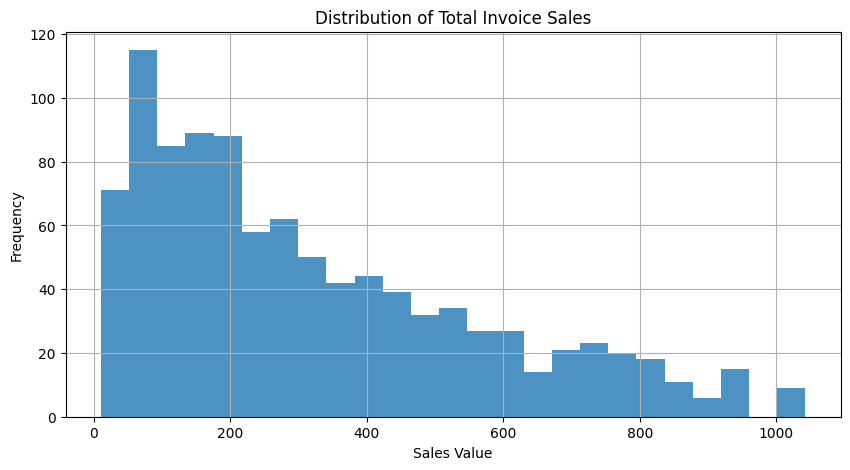

In [41]:
import matplotlib.pyplot as plt

# 1. Plot a Histogram for total sales to see revenue distribution
plt.figure(figsize=(10, 5))
df["Sales"].hist(bins=25, alpha=0.8)
plt.title("Distribution of Total Invoice Sales")
plt.xlabel("Sales Value")
plt.ylabel("Frequency")
plt.show()

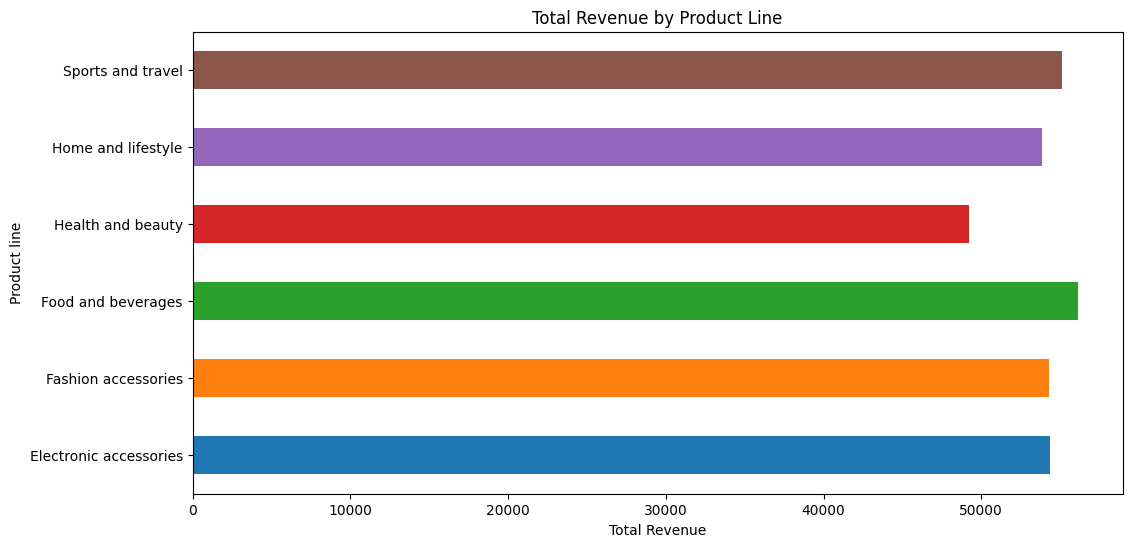

In [43]:
# 2. Group by Product Line and plot a horizontal Bar chart with unique colors
plt.figure(figsize=(12, 6))

# تحديد قائمة بـ 6 ألوان مختلفة لكل قسم من الأقسام الستة
custom_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

# تمرير قائمة الألوان للمعامل color داخل الدالة
df.groupby("Product line")["Sales"].sum().plot(
    kind="barh", 
    color=custom_colors, 
    title="Total Revenue by Product Line"
)

plt.xlabel("Total Revenue")
plt.show()
